In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Visual configuration
sns.set_theme(style="whitegrid")
print("¡Entorno de Sports Analytics configurado correctamente!")

¡Entorno de Sports Analytics configurado correctamente!


In [4]:
# Generación de dataset simulado de monitoreo GPS (60 días)
np.random.seed(42)
dias = pd.date_range(start="2026-06-01", periods=60, freq="D")

# Métricas físicas simuladas
distancia_km = np.random.uniform(4.0, 11.0, size=60)
sprint_m = np.random.uniform(150, 850, size=60)

# Carga diaria integrada (Player Load)
carga_diaria = (distancia_km * 45) + (sprint_m * 0.35) + np.random.normal(0, 10, 60)

# Estructurar DataFrame de pandas
df_atletas = pd.DataFrame({
    "Fecha": dias,
    "Distancia_km": np.round(distancia_km, 2),
    "Sprint_m": np.round(sprint_m, 1),
    "Carga_Diaria": np.round(carga_diaria, 2)
})

df_atletas.head(10)

,Fecha,Distancia_km,Sprint_m,Carga_Diaria
0,2026-06-01,6.62,422.1,438.69
1,2026-06-02,10.66,339.9,595.18
2,2026-06-03,9.12,730.1,662.20
3,2026-06-04,8.19,399.7,493.85
4,2026-06-05,5.09,346.7,353.44
5,2026-06-06,5.09,529.9,417.21
6,2026-06-07,4.41,248.6,285.37
7,2026-06-08,10.06,711.5,699.54
8,2026-06-09,8.21,202.2,425.96
9,2026-06-10,8.96,840.8,693.12


In [5]:
# 1. Carga Aguda: Promedio móvil de los últimos 7 días
df_atletas['Carga_Aguda'] = df_atletas['Carga_Diaria'].rolling(window=7, min_periods=1).mean()

# 2. Carga Crónica: Promedio móvil de los últimos 28 días
df_atletas['Carga_Cronica'] = df_atletas['Carga_Diaria'].rolling(window=28, min_periods=1).mean()

# 3. Cálculo de la Relación ACWR
df_atletas['ACWR'] = df_atletas['Carga_Aguda'] / df_atletas['Carga_Cronica']

# 4. Clasificación por Zona de Riesgo mediante condiciones
condiciones = [
    (df_atletas['ACWR'] < 0.8),
    (df_atletas['ACWR'] >= 0.8) & (df_atletas['ACWR'] <= 1.3),
    (df_atletas['ACWR'] > 1.3) & (df_atletas['ACWR'] < 1.5),
    (df_atletas['ACWR'] >= 1.5)
]

etiquetas = ['Subentrenamiento', 'Zona Optima', 'Advertencia', 'Riesgo Alto (Peligro)']

df_atletas['Zona_Riesgo'] = np.select(condiciones, etiquetas, default='Sin Clasificar')

# Redondear para lectura limpia
df_atletas = df_atletas.round(2)

# Mostrar los últimos 10 días cargados
df_atletas.tail(10)

,Fecha,Distancia_km,Sprint_m,Carga_Diaria,Carga_Aguda,Carga_Cronica,ACWR,Zona_Riesgo
50,2026-07-21,10.79,352.8,592.83,487.80,487.00,1.00,Zona Optima
51,2026-07-22,9.43,262.9,518.01,486.30,492.41,0.99,Zona Optima
52,2026-07-23,10.58,800.8,758.82,523.41,503.37,1.04,Zona Optima
53,2026-07-24,10.26,715.7,720.18,563.52,509.53,1.11,Zona Optima
54,2026-07-25,8.19,593.4,563.65,562.74,512.31,1.10,Zona Optima
55,2026-07-26,10.45,760.0,723.19,599.91,518.21,1.16,Zona Optima
56,2026-07-27,4.62,712.6,462.49,619.88,511.71,1.21,Zona Optima
57,2026-07-28,5.37,280.6,342.91,584.18,511.32,1.14,Zona Optima
58,2026-07-29,4.32,774.8,467.93,577.02,511.35,1.13,Zona Optima
59,2026-07-30,6.28,527.5,470.58,535.85,512.19,1.05,Zona Optima


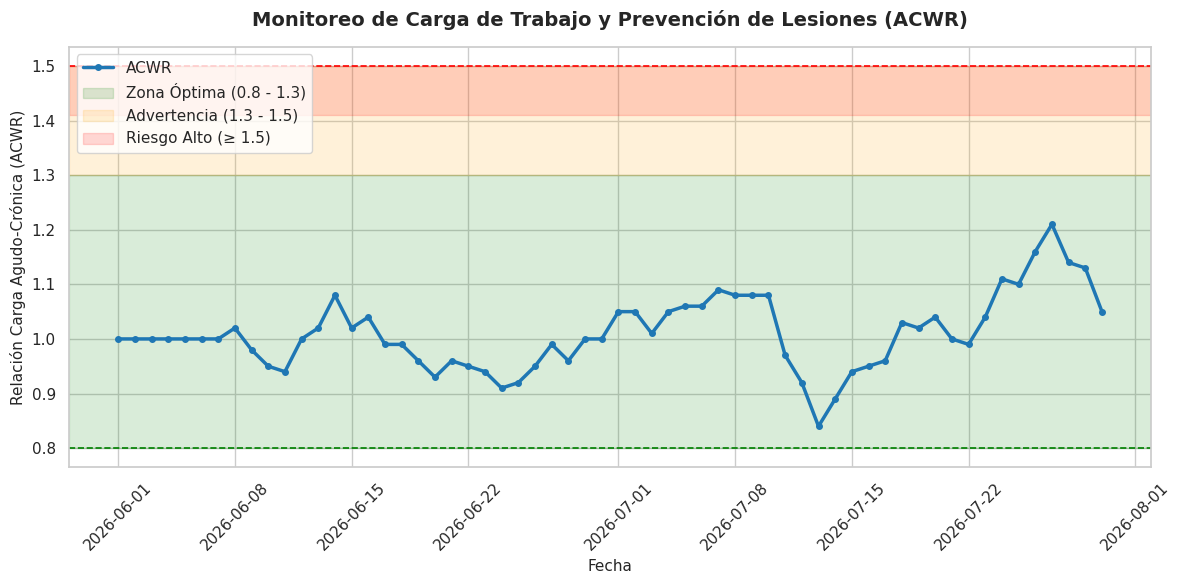

In [6]:
plt.figure(figsize=(12, 6))

# Línea principal del ACWR
plt.plot(df_atletas['Fecha'], df_atletas['ACWR'], label='ACWR', color='#1f77b4', linewidth=2.5, marker='o', markersize=4)

# Sombreado de Zonas de Riesgo
plt.axhspan(0.8, 1.3, color='green', alpha=0.15, label='Zona Óptima (0.8 - 1.3)')
plt.axhspan(1.3, 1.5, color='orange', alpha=0.15, label='Advertencia (1.3 - 1.5)')
plt.axhspan(1.5, df_atletas['ACWR'].max() + 0.2, color='red', alpha=0.15, label='Riesgo Alto (≥ 1.5)')

# Líneas de referencia límite
plt.axhline(y=1.5, color='red', linestyle='--', linewidth=1.2)
plt.axhline(y=0.8, color='green', linestyle='--', linewidth=1.2)

# Personalización del gráfico
plt.title('Monitoreo de Carga de Trabajo y Prevención de Lesiones (ACWR)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Fecha', fontsize=11)
plt.ylabel('Relación Carga Agudo-Crónica (ACWR)', fontsize=11)
plt.xticks(rotation=45)
plt.legend(loc='upper left', frameon=True)
plt.tight_layout()

# Mostrar gráfico
plt.show()

In [7]:
# Guardar dataset procesado a CSV
df_atletas.to_csv('Atleta_Monitoreo_ACWR.csv', index=False)
print("¡Archivo 'Atleta_Monitoreo_ACWR.csv' generado y listo para descargar!")

¡Archivo 'Atleta_Monitoreo_ACWR.csv' generado y listo para descargar!


In [8]:
# Semilla para reproductibilidad
np.random.seed(101)

# Parámetros del plantel
nombres_atletas = [f"Atleta_{i:02d}" for i in range(1, 11)] # 10 Atletas
fechas_escaladas = pd.date_range(start="2026-03-01", periods=120, freq="D") # 4 meses de temporada

registros = []

for atleta in nombres_atletas:
    # Carga base personalizada por atleta (diferentes posiciones/capacidades)
    factor_posicion = np.random.uniform(0.85, 1.15)

    for fecha in fechas_escaladas:
        distancia = np.random.uniform(3.5, 12.0) * factor_posicion
        sprints = np.random.uniform(100, 900) * factor_posicion

        # Simular picos ocasionales de sobrecarga (días de partido)
        pico_partido = 1.35 if np.random.rand() > 0.85 else 1.0
        carga = ((distancia * 40) + (sprints * 0.3)) * pico_partido + np.random.normal(0, 5)

        registros.append({
            "Atleta": atleta,
            "Fecha": fecha,
            "Distancia_km": np.round(distancia, 2),
            "Sprint_m": np.round(sprints, 1),
            "Carga_Diaria": np.round(carga, 2)
        })

# Crear DataFrame escalado
df_plantel = pd.DataFrame(registros)

print(f" Dataset escalado creado con éxito!")
print(f"Total de registros: {len(df_plantel)}")
df_plantel.head(10)


 Dataset escalado creado con éxito!
Total de registros: 1200


,Atleta,Fecha,Distancia_km,Sprint_m,Carga_Diaria
0,Atleta_01,2026-03-01,8.39,123.4,377.23
1,Atleta_01,2026-03-02,6.14,818.9,493.76
2,Atleta_01,2026-03-03,5.14,546.1,372.05
3,Atleta_01,2026-03-04,11.76,287.3,553.81
4,Atleta_01,2026-03-05,8.67,686.6,553.83
5,Atleta_01,2026-03-06,3.93,211.3,230.55
6,Atleta_01,2026-03-07,12.01,519.1,637.66
7,Atleta_01,2026-03-08,11.32,750.0,686.16
8,Atleta_01,2026-03-09,6.57,866.5,523.54
9,Atleta_01,2026-03-10,8.11,842.1,578.12


In [9]:
# Ordenar cronológicamente
df_plantel = df_plantel.sort_values(by=['Atleta', 'Fecha']).reset_index(drop=True)

# Aplicar ventanas móviles de 7 y 28 días agrupando por Atleta
df_plantel['Carga_Aguda'] = df_plantel.groupby('Atleta')['Carga_Diaria'].transform(lambda x: x.rolling(7, min_periods=1).mean())
df_plantel['Carga_Cronica'] = df_plantel.groupby('Atleta')['Carga_Diaria'].transform(lambda x: x.rolling(28, min_periods=1).mean())

# Cálculo de ACWR
df_plantel['ACWR'] = df_plantel['Carga_Aguda'] / df_plantel['Carga_Cronica']

# Clasificación por Zona de Riesgo
condiciones = [
    (df_plantel['ACWR'] < 0.8),
    (df_plantel['ACWR'] >= 0.8) & (df_plantel['ACWR'] <= 1.3),
    (df_plantel['ACWR'] > 1.3) & (df_plantel['ACWR'] < 1.5),
    (df_plantel['ACWR'] >= 1.5)
]

etiquetas = ['Subentrenamiento', 'Zona Optima', 'Advertencia', 'Riesgo Alto (Peligro)']
df_plantel['Zona_Riesgo'] = np.select(condiciones, etiquetas, default='Sin Clasificar')

# Redondear y exportar el CSV escalado
df_plantel = df_plantel.round(2)
df_plantel.to_csv('Plantel_Monitoreo_ACWR_Escalado.csv', index=False)

print(" Dataset procesado y exportado a 'Plantel_Monitoreo_ACWR_Escalado.csv'!")
df_plantel.sample(10) # Muestra aleatoria de varios atletas

 Dataset procesado y exportado a 'Plantel_Monitoreo_ACWR_Escalado.csv'!


,Atleta,Fecha,Distancia_km,Sprint_m,Carga_Diaria,Carga_Aguda,Carga_Cronica,ACWR,Zona_Riesgo
791,Atleta_07,2026-05-11,3.80,210.1,217.99,484.03,502.82,0.96,Zona Optima
377,Atleta_04,2026-03-18,10.71,407.1,553.03,450.53,472.99,0.95,Zona Optima
67,Atleta_01,2026-05-07,10.01,902.5,665.68,455.54,480.77,0.95,Zona Optima
194,Atleta_02,2026-05-14,7.10,825.8,536.20,488.97,532.89,0.92,Zona Optima
738,Atleta_07,2026-03-19,5.89,216.7,304.94,417.51,499.88,0.84,Zona Optima
447,Atleta_04,2026-05-27,10.10,555.7,566.16,490.62,495.79,0.99,Zona Optima
203,Atleta_02,2026-05-23,9.25,633.2,756.62,580.34,551.14,1.05,Zona Optima
1039,Atleta_09,2026-05-19,10.70,637.8,626.56,620.92,557.35,1.11,Zona Optima
448,Atleta_04,2026-05-28,6.93,322.2,372.66,480.49,485.02,0.99,Zona Optima
769,Atleta_07,2026-04-19,8.65,863.2,808.51,619.27,552.49,1.12,Zona Optima


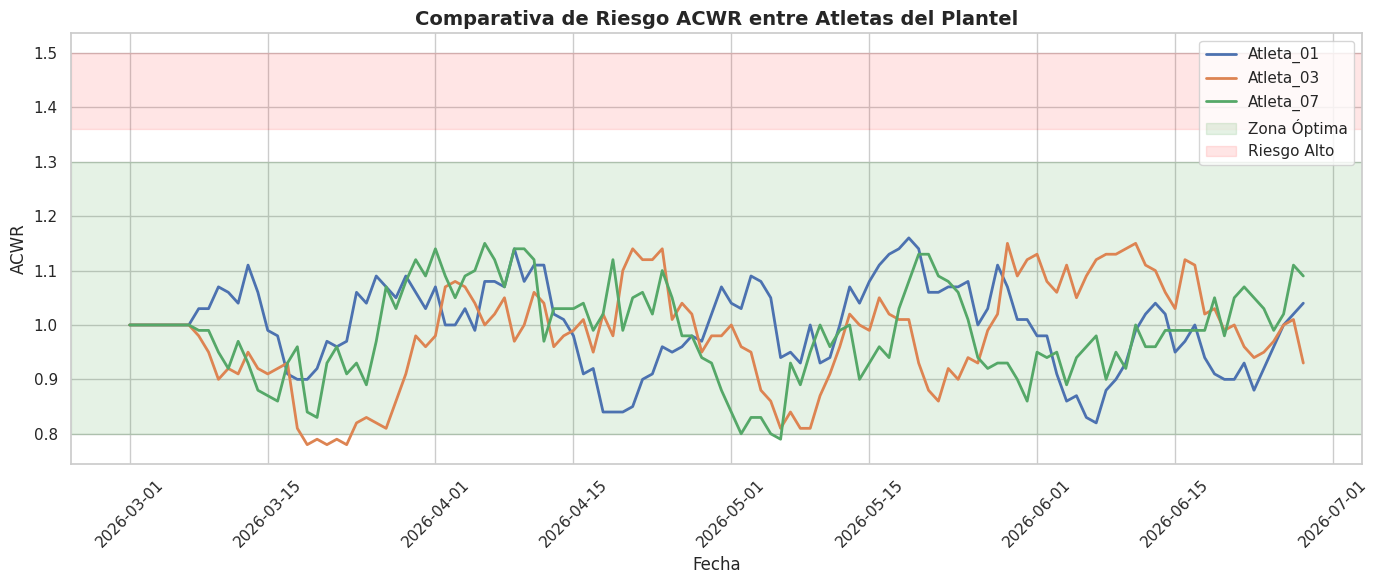

In [10]:
plt.figure(figsize=(14, 6))

# Seleccionar 3 atletas de muestra
muestra_atletas = ['Atleta_01', 'Atleta_03', 'Atleta_07']
df_sub = df_plantel[df_plantel['Atleta'].isin(muestra_atletas)]

sns.lineplot(data=df_sub, x='Fecha', y='ACWR', hue='Atleta', linewidth=2)

plt.axhspan(0.8, 1.3, color='green', alpha=0.1, label='Zona Óptima')
plt.axhspan(1.5, df_sub['ACWR'].max() + 0.2, color='red', alpha=0.1, label='Riesgo Alto')

plt.title('Comparativa de Riesgo ACWR entre Atletas del Plantel', fontsize=14, fontweight='bold')
plt.ylabel('ACWR')
plt.xticks(rotation=45)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()